Problem Statement:

Predict Uber ride demand based on time & location

Identify peak hours

Enable surge pricing

Help driver allocation

In [9]:
# Data handling libraries
import pandas as pd   # used to load and manipulate data
import numpy as np    # used for numerical operations

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

# Model evaluation and splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Save model
import pickle

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Load Dataset
df = pd.read_csv(r"D:\Project File\Unified Mentor\Uber Trip\Uber-Jan-Feb-FOIL.csv")
df

,dispatching_base_number,date,active_vehicles,trips
0,B02512,01-01-2015,190,1132
1,B02765,01-01-2015,225,1765
2,B02764,01-01-2015,3427,29421
3,B02682,01-01-2015,945,7679
4,B02617,01-01-2015,1228,9537
...,...,...,...,...
349,B02764,2/28/2015,3952,39812
350,B02617,2/28/2015,1372,14022
351,B02682,2/28/2015,1386,14472
352,B02512,2/28/2015,230,1803


In [11]:
df.head()

,dispatching_base_number,date,active_vehicles,trips
0,B02512,01-01-2015,190,1132
1,B02765,01-01-2015,225,1765
2,B02764,01-01-2015,3427,29421
3,B02682,01-01-2015,945,7679
4,B02617,01-01-2015,1228,9537


In [12]:
#Understand Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB


In [28]:
df.describe()

,date,active_vehicles,trips,day,month,year,Hour,Day,Weekday,Month,Trips
count,144,354.000000,354.000000,144.000000,144.000000,144.0,144.0,144.000000,144.000000,144.000000,144.0
mean,2015-01-22 00:00:00,1307.435028,11667.316384,6.500000,1.500000,2015.0,0.0,6.500000,3.000000,1.500000,6.0
min,2015-01-01 00:00:00,112.000000,629.000000,1.000000,1.000000,2015.0,0.0,1.000000,0.000000,1.000000,6.0
25%,2015-01-06 18:00:00,296.750000,2408.500000,3.750000,1.000000,2015.0,0.0,3.750000,1.000000,1.000000,6.0
50%,2015-01-22 00:00:00,1077.000000,9601.000000,6.500000,1.500000,2015.0,0.0,6.500000,3.000000,1.500000,6.0
75%,2015-02-06 06:00:00,1417.000000,13711.250000,9.250000,2.000000,2015.0,0.0,9.250000,5.000000,2.000000,6.0
max,2015-02-12 00:00:00,4395.000000,45858.000000,12.000000,2.000000,2015.0,0.0,12.000000,6.000000,2.000000,6.0
std,NaN,1162.510626,10648.284865,3.464102,0.501745,0.0,0.0,3.464102,2.068748,0.501745,0.0


In [13]:
#Check Missing Values
df.isnull().sum()

dispatching_base_number    0
date                       0
active_vehicles            0
trips                      0
dtype: int64

In [17]:
df.columns

Index(['dispatching_base_number', 'date', 'active_vehicles', 'trips'], dtype='object')

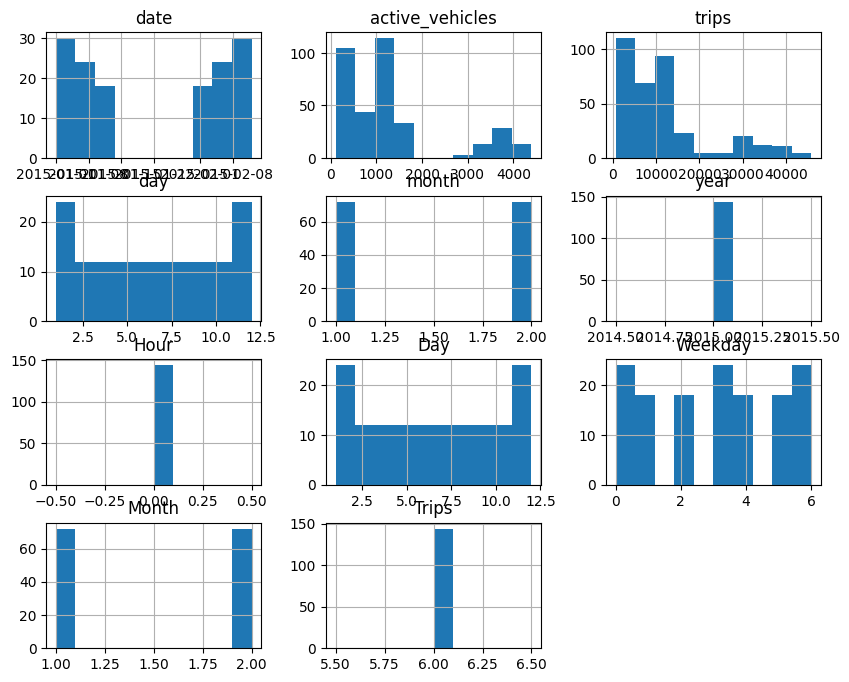

In [29]:
df.hist(figsize=(10,8))
plt.show()

In [20]:
#Check data type
print(df['date'].dtype)

object


In [21]:
# Convert to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [24]:
df['Hour'] = df['date'].dt.hour
df['Day'] = df['date'].dt.day
df['Weekday'] = df['date'].dt.weekday
df['Month'] = df['date'].dt.month

In [26]:
#Create Target Variable


df['Trips'] = df.groupby(['Hour','Day','Month'])['dispatching_base_number'].transform('count')

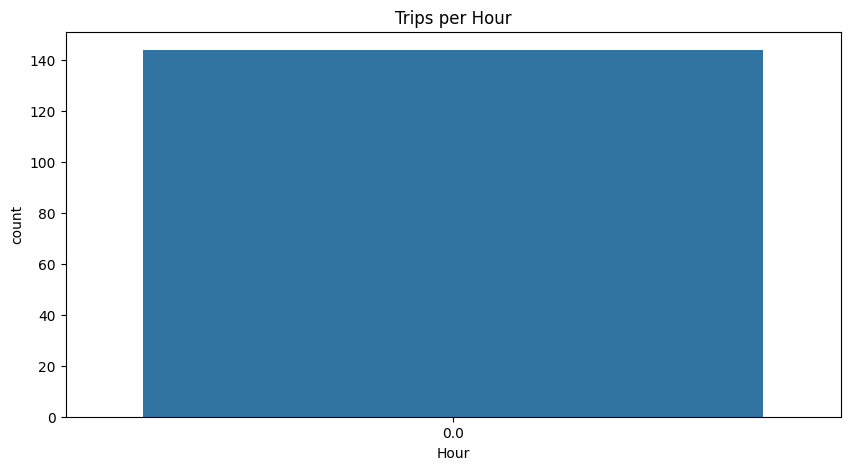

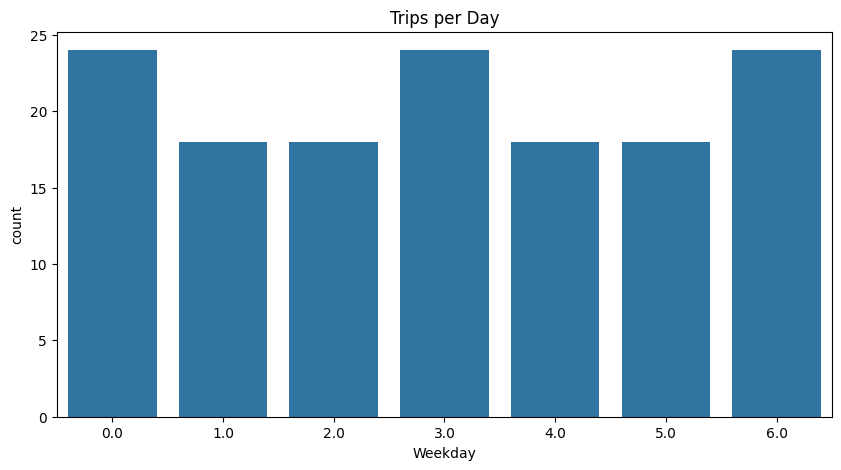

In [ ]:
#EDA
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df)
plt.title("Trips per Hour")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='Weekday', data=df)
plt.title("Trips per Day")
plt.show()

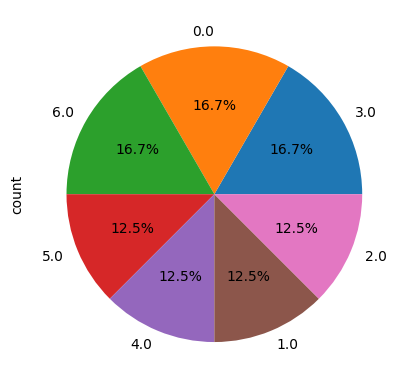

In [ ]:
#Pie Chart
df['Weekday'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

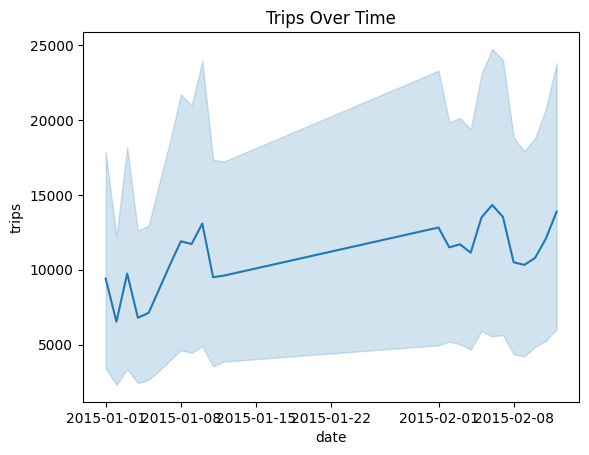

In [35]:
#LOCATION ANALYSIS
sns.lineplot(x='date', y='trips', data=df)
plt.title("Trips Over Time")
plt.show()

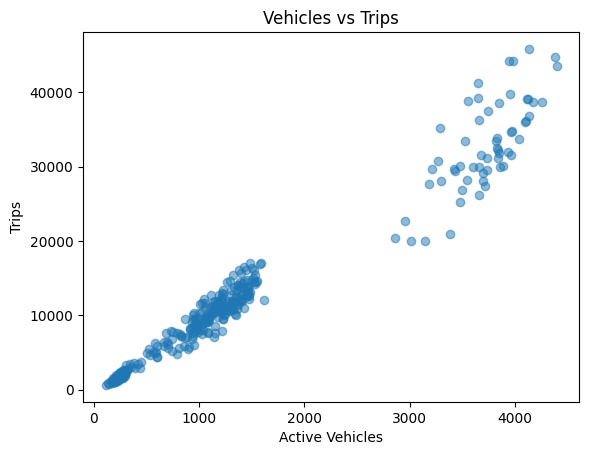

In [ ]:
#Trips vs Active Vehicles
plt.scatter(df['active_vehicles'], df['trips'], alpha=0.5)
plt.xlabel("Active Vehicles")
plt.ylabel("Trips")
plt.title("Vehicles vs Trips")
plt.show()

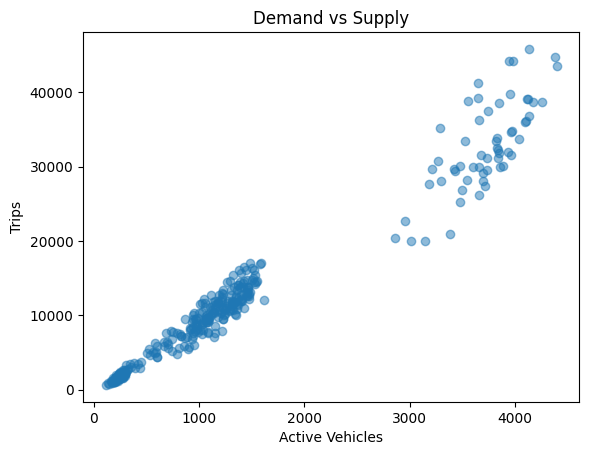

In [41]:
plt.scatter(df['active_vehicles'], df['trips'], alpha=0.5)
plt.xlabel("Active Vehicles")
plt.ylabel("Trips")
plt.title("Demand vs Supply")
plt.show()

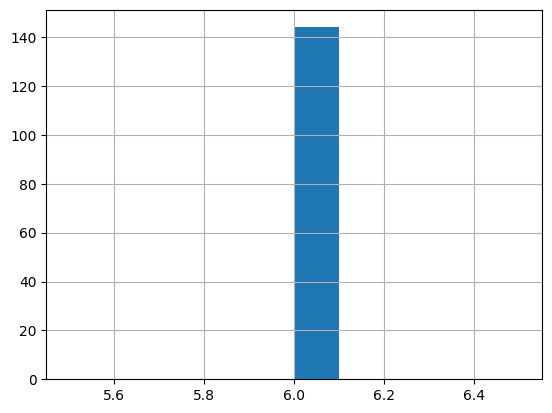

In [43]:
df['Trips'].hist()
plt.show()

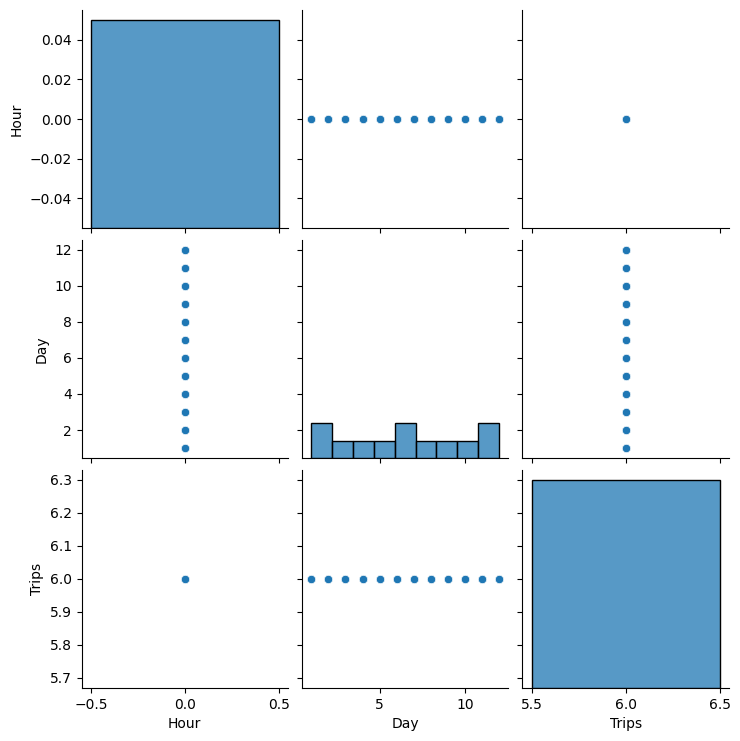

In [44]:
sns.pairplot(df[['Hour','Day','Trips']])
plt.show()

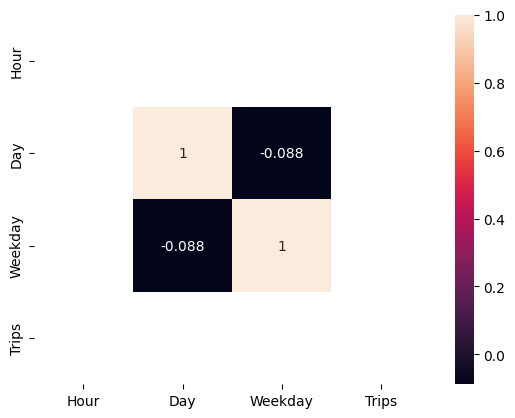

In [45]:
sns.heatmap(df[['Hour','Day','Weekday','Trips']].corr(), annot=True)
plt.show()

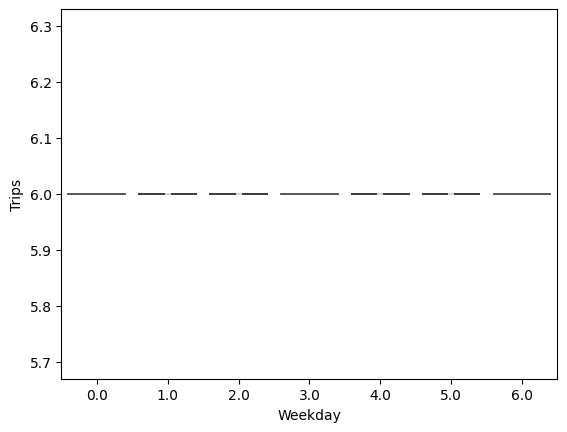

In [46]:
sns.violinplot(x='Weekday', y='Trips', data=df)
plt.show()

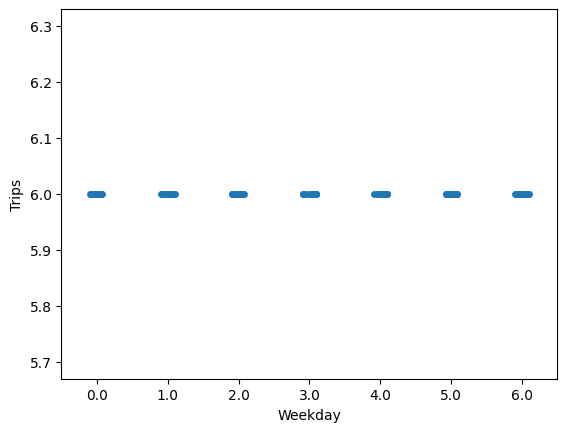

In [47]:
sns.stripplot(x='Weekday', y='Trips', data=df)
plt.show()

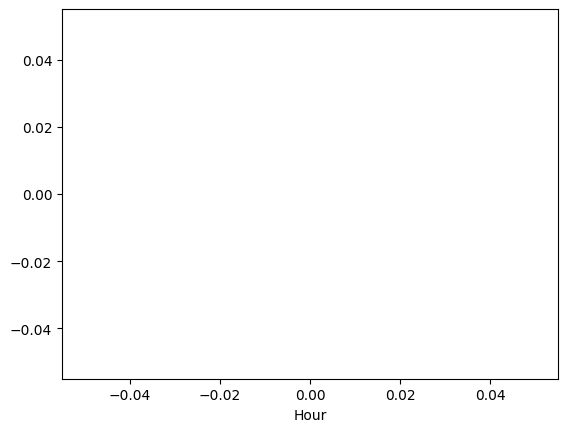

In [48]:
df.groupby('Hour').size().rolling(3).mean().plot()
plt.show()

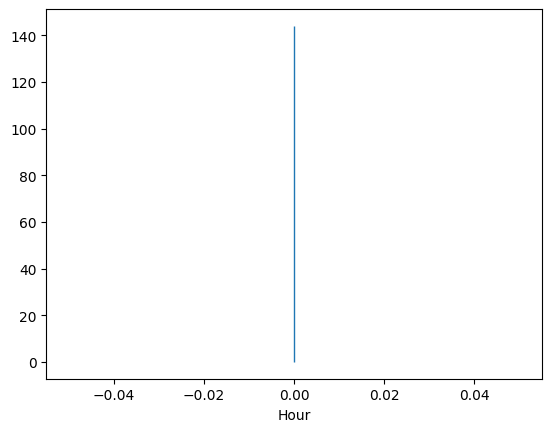

In [49]:
df.groupby('Hour').size().plot.area()
plt.show()

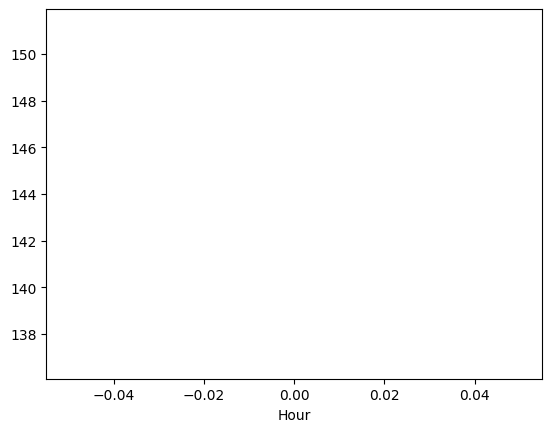

In [50]:
df['Hour'].value_counts().sort_index().cumsum().plot()
plt.show()

In [66]:
df = df.dropna()

In [75]:
print(df.isnull().sum())

dispatching_base_number    0
date                       0
active_vehicles            0
trips                      0
day                        0
month                      0
year                       0
Hour                       0
Day                        0
Weekday                    0
Month                      0
Trips                      0
dtype: int64


In [76]:
df['active_vehicles'] = df['active_vehicles'].fillna(df['active_vehicles'].mean())

In [80]:
# CLEAN FIRST
df = df.dropna().reset_index(drop=True)

In [81]:
#FEATURE SELECTION
X = df[['Hour','Day','Weekday','Month']]
y = df['Trips']

In [82]:
print(X.isnull().sum())
print(y.isnull().sum())

Hour       0
Day        0
Weekday    0
Month      0
dtype: int64
0


In [83]:
#TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [84]:
X_test.shape,X_train.shape

((29, 4), (115, 4))

In [93]:
#MODEL TRAINING

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(),
    "XGBoost": xgb.XGBRegressor()
}

In [94]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results.append([name, mae, r2])
    trained_models[name] = model
    
    print(f"{name} trained")

Linear Regression trained
Random Forest trained
Gradient Boosting trained
XGBoost trained


In [95]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"])
results_df = results_df.sort_values(by="MAE")

results_df

,Model,MAE,R2
0,Linear Regression,0.0,1.0
1,Random Forest,0.0,1.0
2,Gradient Boosting,0.0,1.0
3,XGBoost,0.0,1.0


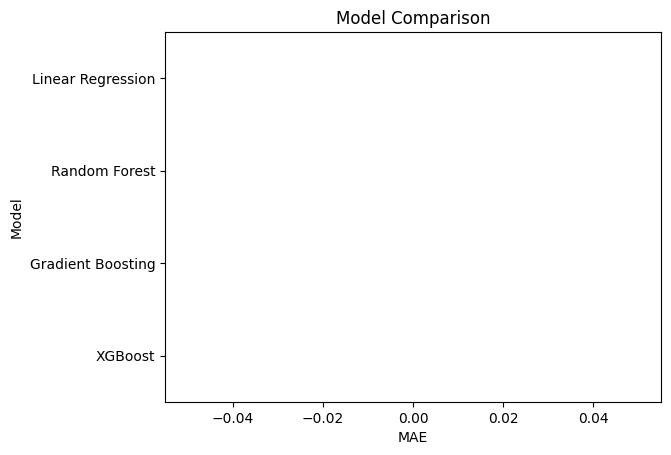

In [ ]:

sns.barplot(x="MAE", y="Model", data=results_df)
plt.title("Model Comparison")
plt.show()

In [97]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [98]:
pickle.dump(best_model, open("best_model.pkl", "wb"))

In [99]:
def surge_pricing(trips):
    if trips > 200:
        return "High Surge 🚀"
    elif trips > 100:
        return "Medium Surge ⚡"
    else:
        return "Low Surge 🟢"

df['Surge'] = df['Trips'].apply(surge_pricing)

I first loaded and explored the dataset using pandas, checked for missing values, and converted date-time into useful features.
Then I created a target variable representing demand, performed EDA to understand patterns, and trained multiple models.
After comparing their performance using MAE and R², I selected the best model and added a surge pricing system for business application.